In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt

In [14]:
np.random.seed(42)
n = 2000

income = np.random.normal(50000, 15000, n).clip(10000, 150000)
debt = np.random.normal(15000, 8000, n).clip(0, 80000)
age = np.random.randint(21, 65, n)
payment_history_score = np.random.normal(650, 80, n).clip(300, 850)
num_late_payments = np.random.poisson(1.5, n)
credit_utilization = np.random.uniform(0, 1, n)
employment_years = np.random.randint(0, 30, n)

# --- FIX: standardize (z-score) each raw feature before combining ---
# This stops any single feature's scale (like income in the 10,000s)
# from swamping the others in the risk formula.
def z(x):
    return (x - x.mean()) / x.std()

risk_score = (
    -0.8 * z(income)
    + 0.6 * z(debt)
    - 1.2 * z(payment_history_score)
    + 0.7 * z(num_late_payments)
    + 0.9 * z(credit_utilization)
    - 0.5 * z(employment_years)
)

prob_default = 1 / (1 + np.exp(-(risk_score - 0.7)))  # -0.7 tunes ~25-30% default rate
default = np.random.binomial(1, prob_default)

df = pd.DataFrame({
    'income': income, 'debt': debt, 'age': age,
    'payment_history_score': payment_history_score,
    'num_late_payments': num_late_payments,
    'credit_utilization': credit_utilization,
    'employment_years': employment_years,
    'default': default
})

print(df['default'].value_counts())  # sanity check: should show both 0 and 1 with a reasonable split
df.head()

default
0    1210
1     790
Name: count, dtype: int64


,income,debt,age,payment_history_score,num_late_payments,credit_utilization,employment_years,default
0,57450.712295,9598.573800,44,664.810003,3,0.178196,17,0
1,47926.035482,13843.850634,30,533.950268,1,0.041308,27,0
2,59715.328072,8660.640632,28,709.531823,0,0.809238,9,0
3,72845.447846,12536.307763,41,760.923211,2,0.551705,14,0
4,46487.699379,0.000000,26,695.719579,3,0.316749,29,0


In [15]:
df['debt_to_income'] = df['debt'] / df['income']
df.describe()

,income,debt,age,payment_history_score,num_late_payments,credit_utilization,employment_years,default,debt_to_income
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,50689.663590,15038.635391,42.816000,651.511943,1.501500,0.500246,14.493000,0.395000,0.333668
std,14787.865119,7845.272770,12.664531,79.653528,1.246505,0.286411,8.595807,0.488973,0.241972
min,10000.000000,0.000000,21.000000,404.843450,0.000000,0.003373,0.000000,0.000000,0.000000
25%,40660.071481,9326.992249,32.000000,597.042110,1.000000,0.254704,7.000000,0.000000,0.182872
50%,50670.374839,14999.573569,43.000000,652.316064,1.000000,0.493196,14.500000,0.000000,0.297870
75%,60244.663902,20324.349446,54.000000,707.028149,2.000000,0.738453,22.000000,1.000000,0.429748
max,107790.972360,46409.901651,64.000000,850.000000,8.000000,0.999893,29.000000,1.000000,2.662503


In [16]:
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)  # tree models don't need scaling

RandomForestClassifier(n_estimators=200, random_state=42)

In [18]:
def evaluate(name, y_true, y_pred, y_prob):
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-Score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_prob))
    print(classification_report(y_true, y_pred))

evaluate("Logistic Regression", y_test, log_reg.predict(X_test_scaled), log_reg.predict_proba(X_test_scaled)[:,1])
evaluate("Random Forest", y_test, rf.predict(X_test), rf.predict_proba(X_test)[:,1])

--- Logistic Regression ---
Accuracy: 0.785
Precision: 0.7368421052631579
Recall: 0.7088607594936709
F1-Score: 0.7225806451612903
ROC-AUC: 0.8721362067161836
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       242
           1       0.74      0.71      0.72       158

    accuracy                           0.79       400
   macro avg       0.78      0.77      0.77       400
weighted avg       0.78      0.79      0.78       400

--- Random Forest ---
Accuracy: 0.7875
Precision: 0.7517241379310344
Recall: 0.689873417721519
F1-Score: 0.7194719471947195
ROC-AUC: 0.846610524113401
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       242
           1       0.75      0.69      0.72       158

    accuracy                           0.79       400
   macro avg       0.78      0.77      0.77       400
weighted avg       0.79      0.79      0.79       400



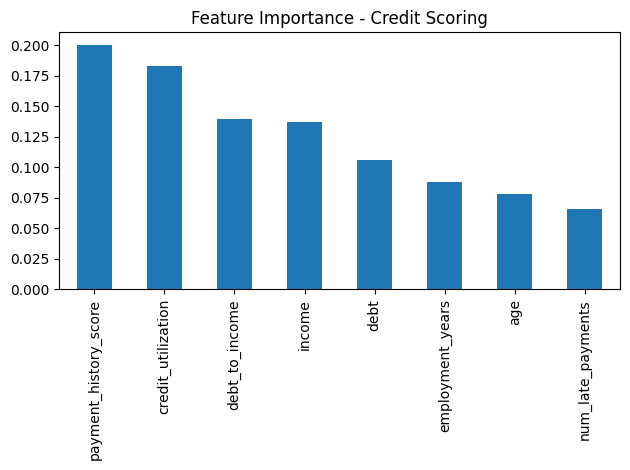

In [19]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.plot(kind='bar', title='Feature Importance - Credit Scoring')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()